In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
from tensorflow.keras.layers import LeakyReLU

In [2]:
csv='Alloy_Dataset.csv'
df=pd.read_csv(csv)
df

,Lifespan,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects,seedLocation,castType
0,1469.17,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0,Bottom,Die
1,1793.64,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0,Bottom,Investment
2,700.60,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0,Bottom,Investment
3,1082.10,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0,Top,Continuous
4,1838.83,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0,Top,Die
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1217.50,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0,Bottom,Investment
996,742.05,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0,Bottom,Investment
997,1448.26,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0,Bottom,Investment
998,1099.10,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0,Top,Continuous


In [3]:
df['largeDefects'].value_counts()

largeDefects
0    782
3     59
4     54
1     53
2     52
Name: count, dtype: int64

In [4]:
df['castType'].value_counts()

castType
Die           366
Continuous    327
Investment    307
Name: count, dtype: int64

In [5]:
df['seedLocation'].value_counts()

seedLocation
Top       503
Bottom    497
Name: count, dtype: int64

In [6]:
df['microstructure'].value_counts()

microstructure
singleGrain    343
equiGrain      340
colGrain       317
Name: count, dtype: int64

In [7]:
df_numerical=df[['coolingRate','quenchTime','forgeTime','HeatTreatTime','Nickel%', 'Iron%','Cobalt%','Chromium%','smallDefects','largeDefects','sliverDefects']]

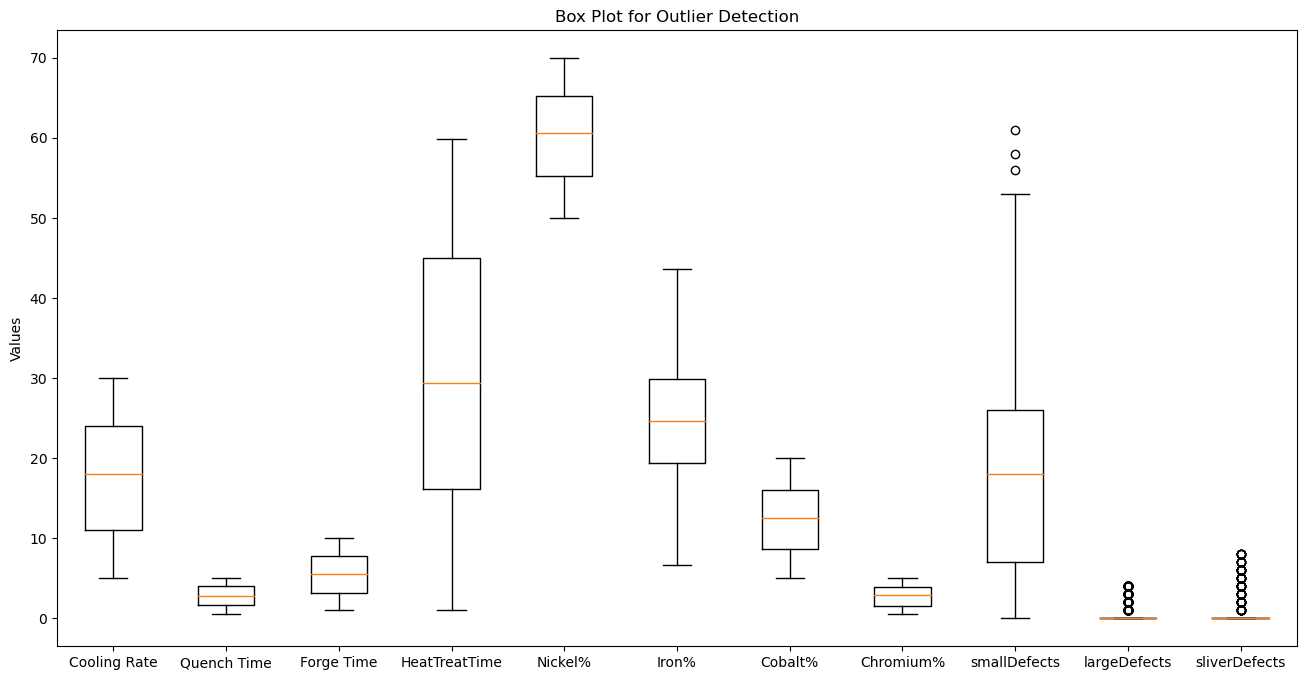

In [8]:
#Plot to check the outliers
plt.figure(figsize=(16,8))
plt.boxplot(df_numerical, 
            labels=['Cooling Rate', 'Quench Time', 'Forge Time','HeatTreatTime','Nickel%', 'Iron%','Cobalt%','Chromium%','smallDefects','largeDefects','sliverDefects'])
plt.title('Box Plot for Outlier Detection')
plt.ylabel('Values')
plt.show()

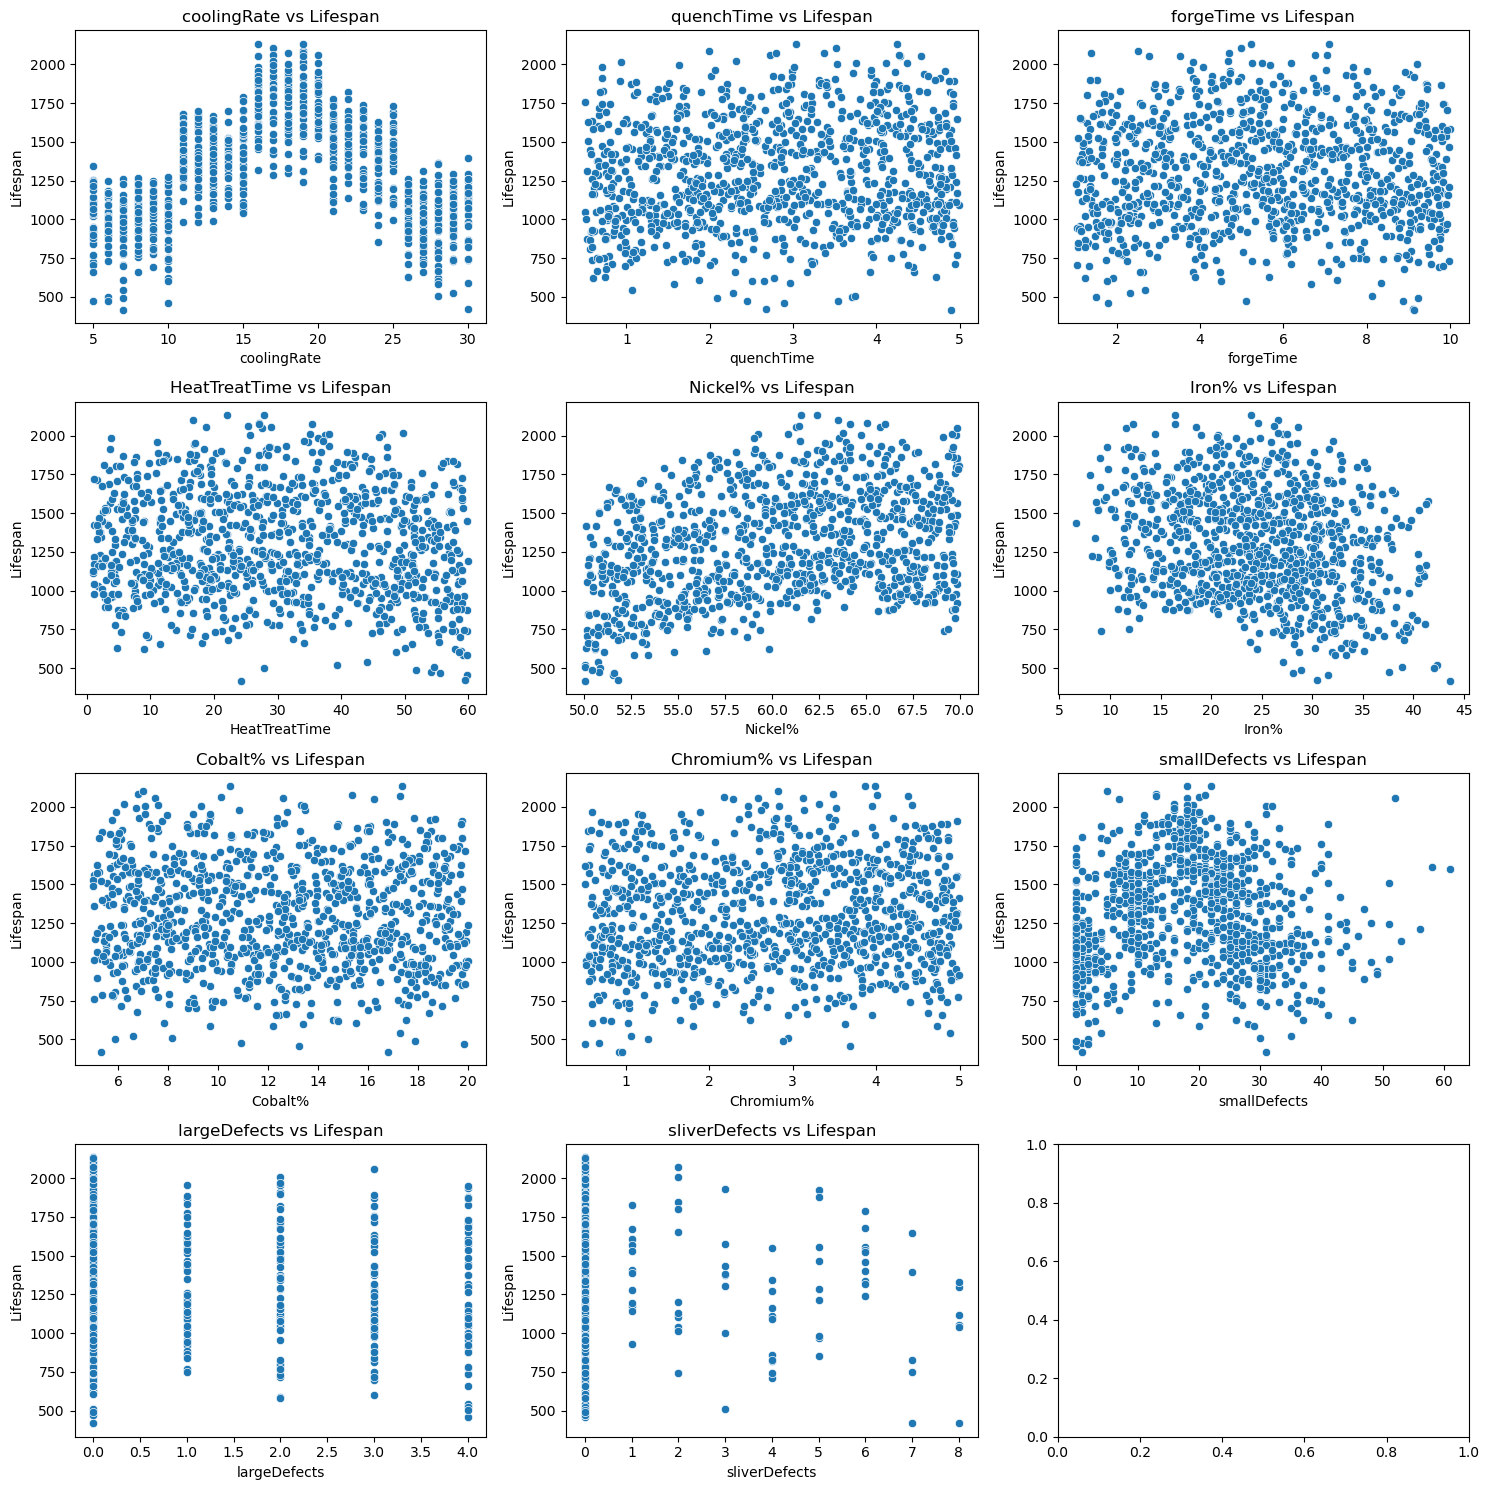

In [9]:
#Distribution of the numerical data
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
axes = axes.flatten()
for i, column in enumerate(df_numerical):
    sns.scatterplot(data=df, x=column, y='Lifespan', ax=axes[i])
    axes[i].set_title(f'{column} vs Lifespan')
if len(df_numerical) < len(axes):
    fig.delaxes(axes[len(df_numerical)])
plt.tight_layout()
plt.show()


<Figure size 15000x7500 with 0 Axes>

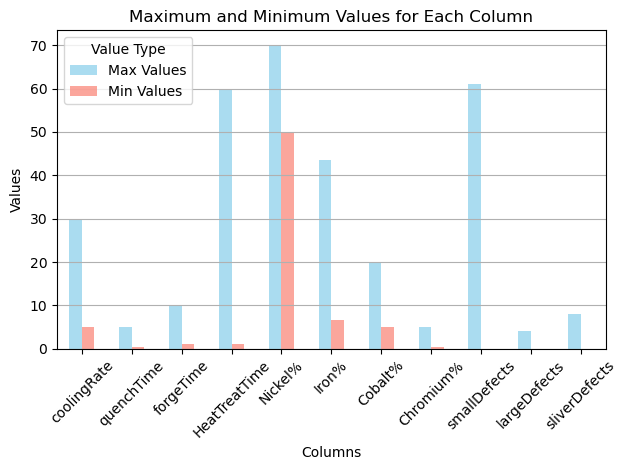

In [10]:
#Bar Plot to show the min-max values
max_values = df_numerical.max()
min_values = df_numerical.min()

summary_df = pd.DataFrame({'Max Values': max_values, 'Min Values': min_values})
plt.figure(figsize=(150, 75))
summary_df.plot(kind='bar', color=['skyblue', 'salmon'], alpha=0.7)

plt.title('Maximum and Minimum Values for Each Column')
plt.xlabel('Columns')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()  
plt.legend(title='Value Type')
plt.show()

In [11]:
#Separating dependent and independent variables
y = df.iloc[:, 0]  
X = df.iloc[:, 1:]  

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
X

Shape of X: (1000, 15)
Shape of y: (1000,)


,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects,seedLocation,castType
0,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0,Bottom,Die
1,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0,Bottom,Investment
2,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0,Bottom,Investment
3,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0,Top,Continuous
4,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0,Top,Die
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0,Bottom,Investment
996,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0,Bottom,Investment
997,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0,Bottom,Investment
998,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0,Top,Continuous


In [12]:
X

,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects,seedLocation,castType
0,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0,Bottom,Die
1,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0,Bottom,Investment
2,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0,Bottom,Investment
3,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0,Top,Continuous
4,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0,Top,Die
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0,Bottom,Investment
996,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0,Bottom,Investment
997,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0,Bottom,Investment
998,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0,Top,Continuous


In [13]:
#One hot encoding
one_hot_encoder = OneHotEncoder(sparse=False, drop='first')
one_hot_encoded = one_hot_encoder.fit_transform(X[['partType','castType','microstructure']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=one_hot_encoder.get_feature_names_out(['partType','castType','microstructure']))
label_encoder_seed = LabelEncoder()
seed_location_encoded = label_encoder_seed.fit_transform(X['seedLocation'])

seed_location_encoded=pd.DataFrame(seed_location_encoded, columns=['seedLocation'])
scaler = MinMaxScaler()
scaled_columns = scaler.fit_transform(X[['coolingRate', 'quenchTime', 'forgeTime', 'HeatTreatTime', 'smallDefects', 'largeDefects', 'sliverDefects']])

divided_columns = scaler.fit_transform(X[['Nickel%', 'Iron%', 'Cobalt%', 'Chromium%']])
X = pd.concat([
    one_hot_df,
    pd.DataFrame(scaled_columns, columns=['coolingRate', 'quenchTime', 'forgeTime', 'HeatTreatTime', 'smallDefects', 'largeDefects', 'sliverDefects']),
    pd.DataFrame(divided_columns, columns=['Nickel%', 'Iron%', 'Cobalt%', 'Chromium%']),
    seed_location_encoded
], axis=1)


/Users/bogdanpetrus/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [14]:
X

,partType_Block,partType_Nozzle,partType_Valve,castType_Die,castType_Investment,microstructure_equiGrain,microstructure_singleGrain,coolingRate,quenchTime,forgeTime,HeatTreatTime,smallDefects,largeDefects,sliverDefects,Nickel%,Iron%,Cobalt%,Chromium%,seedLocation
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.32,0.743875,0.606466,0.778533,0.163934,0.00,0.0,0.788259,0.266559,0.788243,0.093750,0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.56,0.472160,0.273133,0.741678,0.311475,0.00,0.0,0.210738,0.776426,0.074816,0.837054,0
2,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.92,0.057906,0.034560,0.144531,0.573770,0.75,0.0,0.090818,0.791836,0.253173,0.647321,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.16,0.336303,0.129320,0.327106,0.000000,0.25,0.0,0.351731,0.450662,0.790915,0.506696,1
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.44,0.808463,0.316611,0.256454,0.163934,0.00,0.0,0.481686,0.559881,0.429526,0.234375,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.00,0.314031,0.838350,0.572860,0.000000,0.00,0.0,0.907677,0.380373,0.142285,0.781250,0
996,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.20,0.037862,0.775920,0.767323,0.016393,0.00,0.0,0.061716,0.688294,0.481630,0.868304,0
997,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.48,0.583519,0.733556,0.999321,0.262295,0.25,0.0,0.204215,0.717491,0.286573,0.645089,0
998,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.72,0.886414,0.151616,0.283458,0.180328,0.00,0.0,0.015053,0.682887,0.533734,0.946429,1


In [15]:
#Convert data to numpy arrays
y = y.to_numpy()
X = X.to_numpy()

In [16]:
#Scalling the data 
scaler_Y = MinMaxScaler()
y = scaler_Y.fit_transform(y.reshape(-1, 1))  

In [17]:
#Split Test Train Set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [18]:
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),  
    tf.keras.layers.Dense(128),
    LeakyReLU(alpha=0.1), 
    tf.keras.layers.Dense(64),
    LeakyReLU(alpha=0.1), 
     tf.keras.layers.Dense(32),
    LeakyReLU(alpha=0.1), 
    tf.keras.layers.Dense(16),
    LeakyReLU(alpha=0.1), 
    tf.keras.layers.Dense(8),
    LeakyReLU(alpha=0.1), 
    tf.keras.layers.Dense(4),
    LeakyReLU(alpha=0.1), 
    tf.keras.layers.Dense(1, activation='linear') 
])


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mean_absolute_error'])


history = model.fit(X_train, y_train, epochs=90, validation_data=(X_test, y_test), verbose=1)



2024-11-24 11:19:13.562873: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2024-11-24 11:19:13.562899: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2024-11-24 11:19:13.562905: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2024-11-24 11:19:13.562929: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-11-24 11:19:13.562940: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/90


2024-11-24 11:19:13.971573: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2024-11-24 11:19:13.995398: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


27/27 [==============================] - 3s 29ms/step - loss: 0.0930 - mean_absolute_error: 0.2477 - val_loss: 0.0406 - val_mean_absolute_error: 0.1606
Epoch 2/90
27/27 [==============================] - 0s 5ms/step - loss: 0.0413 - mean_absolute_error: 0.1684 - val_loss: 0.0371 - val_mean_absolute_error: 0.1570
Epoch 3/90
27/27 [==============================] - 0s 5ms/step - loss: 0.0378 - mean_absolute_error: 0.1624 - val_loss: 0.0340 - val_mean_absolute_error: 0.1525
Epoch 4/90
27/27 [==============================] - 0s 5ms/step - loss: 0.0352 - mean_absolute_error: 0.1568 - val_loss: 0.0318 - val_mean_absolute_error: 0.1490
Epoch 5/90
27/27 [==============================] - 0s 5ms/step - loss: 0.0330 - mean_absolute_error: 0.1526 - val_loss: 0.0306 - val_mean_absolute_error: 0.1467
Epoch 6/90
27/27 [==============================] - 0s 5ms/step - loss: 0.0316 - mean_absolute_error: 0.1479 - val_loss: 0.0326 - val_mean_absolute_error: 0.1522
Epoch 7/90
27/27 [====================

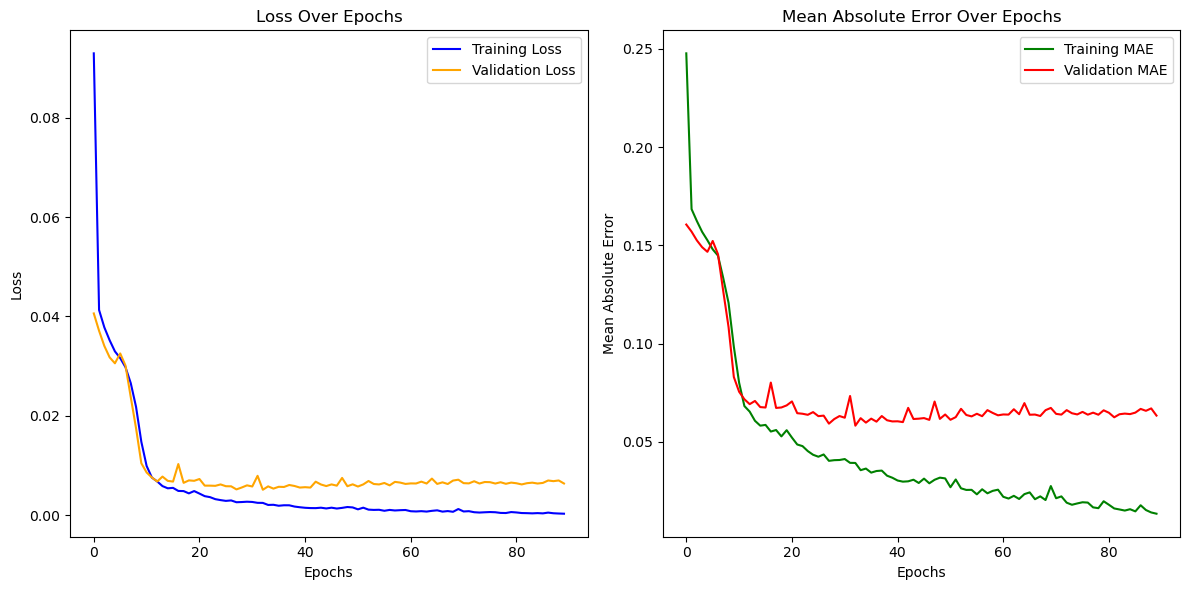

In [19]:
# Plotting the training history
plt.figure(figsize=(12, 6))
# Plot the loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot the MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE', color='green')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE', color='red')
plt.title('Mean Absolute Error Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

In [20]:
#Check efficiency
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100


print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2*100:.2f}%")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


5/5 [==============================] - 0s 24ms/step
Mean Absolute Error (MAE): 0.063323065352347
Mean Squared Error (MSE): 0.006367224225046482
Root Mean Squared Error (RMSE): 0.07979488846440279
R-squared (R2): 82.51%
Mean Absolute Percentage Error (MAPE): 15.39%


In [21]:
#Compare real values with predicted
y_pred_scaled = model.predict(X_test)
y_pred = scaler_Y.inverse_transform(y_pred_scaled) 
y_test_inverse = scaler_Y.inverse_transform(y_test.reshape(-1, 1)) 


comparison_df = pd.DataFrame({
    'Actual': y_test_inverse.flatten(),
    'Predicted': y_pred.flatten() 
})


print(comparison_df)


5/5 [==============================] - 0s 2ms/step
      Actual    Predicted
0    1574.92  1745.052124
1    1803.92  2025.930054
2     975.02  1066.255127
3    1388.75  1711.887451
4    1318.77  1187.664185
..       ...          ...
145  1183.49  1324.561401
146  1072.36  1126.031616
147  1847.65  1611.998901
148  1113.92  1082.318726
149  1761.96  1969.438965

[150 rows x 2 columns]


In [22]:
#Separating dependent and independent variables
y2 = df.iloc[:, 0]  
X2 = df.iloc[:, 1:]  

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (1000, 19)
Shape of y: (1000, 1)


In [23]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
one_hot_encoder = OneHotEncoder(sparse=False, drop='first')
one_hot_encoded = one_hot_encoder.fit_transform(X2[['partType', 'castType']])

# Create DataFrame for the one-hot encoded columns
one_hot_df = pd.DataFrame(one_hot_encoded, columns=one_hot_encoder.get_feature_names_out(['partType', 'castType']))

# Label encoding for 'microstructure' and 'seedLocation'
label_encoder_microstructure = LabelEncoder()
label_encoder_seed = LabelEncoder()

# Fit and transform for 'microstructure' and 'seedLocation'
microstructure_encoded = label_encoder_microstructure.fit_transform(X2['microstructure'])
seed_encoded = label_encoder_seed.fit_transform(X2['seedLocation'])

# Convert encoded arrays to DataFrames
microstructure_encoded_df = pd.DataFrame(microstructure_encoded, columns=['microstructure'])
seed_encoded_df = pd.DataFrame(seed_encoded, columns=['seedLocation'])

# Concatenate all processed DataFrames
X2 = pd.concat([
    one_hot_df,
    microstructure_encoded_df,
    seed_encoded_df,
    X2.drop(columns=['partType', 'microstructure', 'seedLocation', 'castType'])  # Drop original categorical columns
], axis=1)

/Users/bogdanpetrus/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [24]:
X2

,partType_Block,partType_Nozzle,partType_Valve,castType_Die,castType_Investment,microstructure,seedLocation,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects
0,0.0,1.0,0.0,1.0,0.0,1,0,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0
1,1.0,0.0,0.0,0.0,1.0,2,0,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0
2,0.0,0.0,0.0,0.0,1.0,1,0,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0
3,0.0,1.0,0.0,0.0,0.0,0,1,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0
4,0.0,0.0,0.0,1.0,0.0,0,1,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,1.0,2,0,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0
996,1.0,0.0,0.0,0.0,1.0,2,0,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0
997,0.0,1.0,0.0,0.0,1.0,1,0,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0
998,0.0,0.0,1.0,0.0,0.0,0,1,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0


In [25]:
y2 = y2.to_numpy()
X2 = X2.to_numpy()

In [26]:
#Split Test Train Set
from sklearn.model_selection import train_test_split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.15, random_state=42)

In [27]:
# Initialize the Random Forest Regressor with a specified number of trees (e.g., 100 trees)
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train2, y_train2)

y_pred2 = model.predict(X_test2)

mae = mean_absolute_error(y_test2, y_pred2)
mse = mean_squared_error(y_test2, y_pred2)
rmse = mean_squared_error(y_test2, y_pred2, squared=False)  # RMSE
r2 = r2_score(y_test2, y_pred2)
mape = np.mean(np.abs((y_test2 - y_pred2) / y_test2)) * 100

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2 * 100:.2f}%")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 68.92240733333328
Mean Squared Error (MSE): 7265.730675023396
Root Mean Squared Error (RMSE): 85.2392554814001
R-squared (R2): 93.23%
Mean Absolute Percentage Error (MAPE): 6.05%


In [28]:
#Comparing real values with predicted values
comparison_df = pd.DataFrame({
    'Actual': y_test2,
    'Predicted': y_pred2
})

print(comparison_df)

      Actual  Predicted
0    1574.92  1524.9529
1    1803.92  1965.8983
2     975.02   992.0733
3    1388.75  1437.1012
4    1318.77  1430.3904
..       ...        ...
145  1183.49  1070.9055
146  1072.36  1265.0380
147  1847.65  1847.0253
148  1113.92  1088.3173
149  1761.96  1646.9445

[150 rows x 2 columns]
